# 18 — Análisis de una liga (La Liga): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "La Liga"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

La Liga: 8,957 jugador-temporadas, 3,006 jugadores, 35 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,20,38.0,555,0.993,0.996
2011-2012,20,38.0,551,0.992,0.997
2012-2013,20,38.0,551,0.990,0.995
2013-2014,20,38.0,542,0.991,0.997
2014-2015,20,38.0,527,0.992,0.997
2015-2016,20,38.0,546,0.976,0.997
2016-2017,20,38.0,555,0.993,0.998
2017-2018,20,38.0,573,0.994,0.998
2018-2019,20,38.0,544,0.996,0.998


20 equipos y 38 partidos en las 16 temporadas; 8,957 jugador-temporadas de 3,006 jugadores en 35 clubes. La cobertura
de minutos es del 99.5-99.8% (mediana), con un mínimo de 94.4% en 2011-12.

Esa temporada tiene un problema aparte: FBref registra los partidos de los porteros de **Mallorca, Getafe, Levante y
Real Betis**, pero deja sus victorias, empates y derrotas casi en cero. Como los resultados del equipo se reconstruyen
con los G/E/P de sus porteros, esos cuatro equipos aparecen **sin puntos por partido** (vacío, no cero) en todas las
tablas y gráficas: `liga.resumen_equipos` los detecta comparando los partidos "con resultado" contra los minutos de
sus porteros. En el resto del panel solo hay otros 3 casos así (uno en Liga MX, uno en Ligue 1 y uno en Serie A).

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

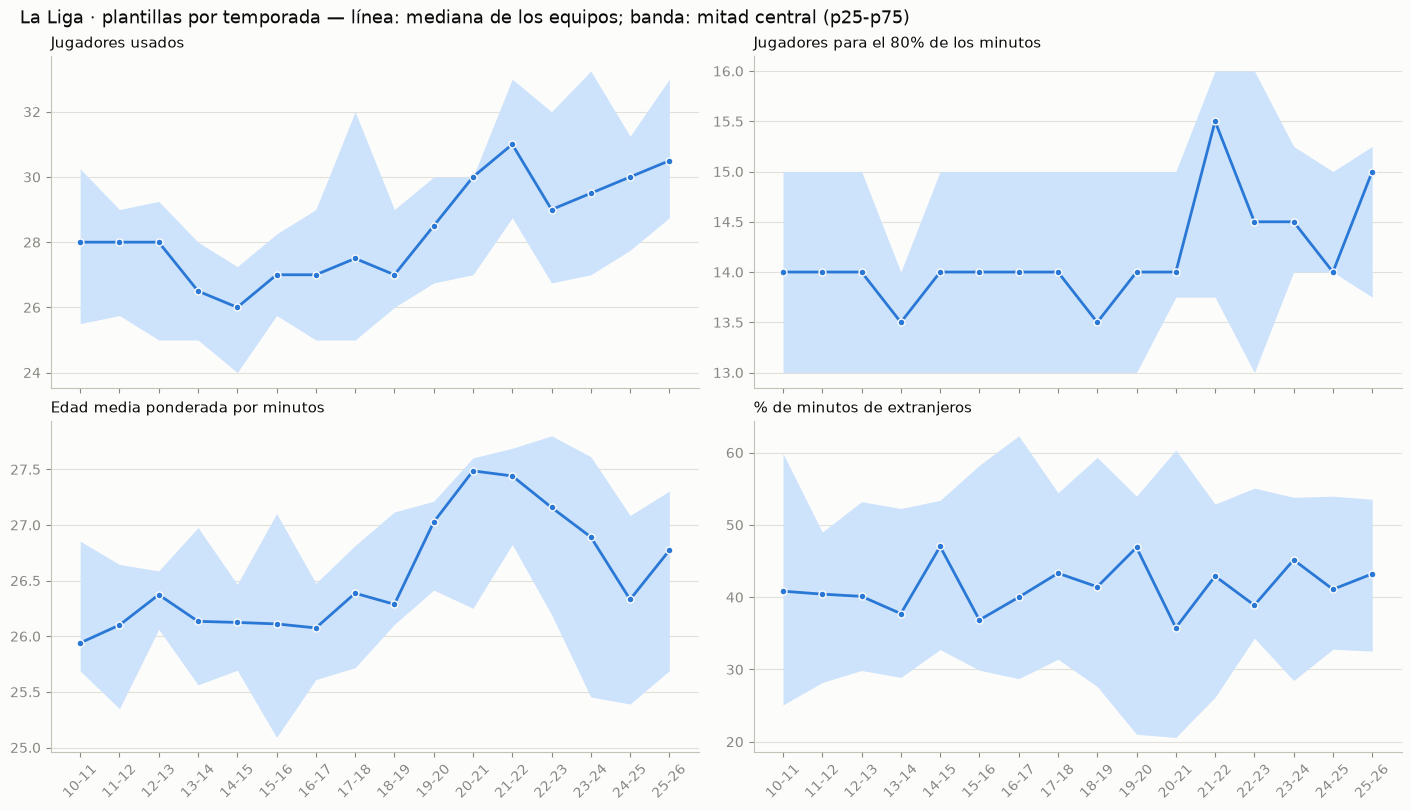

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

- **La rotación creció, pero menos que en la Liga MX**: los jugadores usados pasaron de 26-28 (2010-18) a 29-31
  (2020-26), y los necesarios para el 80% de los minutos de 13.5-14 a 14-15.5.
- **Los extranjeros no tienen tendencia**: sus minutos oscilan entre el 36% y el 47% durante los 15 años (40.8% en
  2010-11, 43.2% en 2025-26), muy lejos del 73% de la Premier. Es la liga más "local" de las tres analizadas.
- **Plantillas algo más viejas**: la edad de quien juega subió de 25.9 a un máximo de 27.5 (2020-21) y hoy está en
  26.8.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
140,2017-2018,Las Palmas,36,19,26.5,45.1,0.6
282,2024-2025,Valladolid,38,19,25.1,58.3,0.4
79,2013-2014,Real Betis,33,18,26.2,30.3,0.7
130,2016-2017,Granada,35,18,24.3,77.6,0.5
201,2020-2021,Valladolid,32,18,27.8,27.8,0.8
253,2022-2023,Sevilla,35,18,28.3,70.8,1.3


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
57,2012-2013,Real Sociedad,22,11,24.8,28.6,1.7
75,2013-2014,Atlético Madrid,25,11,26.4,50.2,2.4
99,2014-2015,Celta Vigo,23,11,25.7,48.3,1.3
251,2022-2023,Rayo Vallecano,28,11,27.3,38.1,1.3
4,2010-2011,Villarreal,28,12,25.9,30.5,1.6
5,2010-2011,Mallorca,24,12,25.9,61.4,1.2


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.28


Rotar se asocia con perder, como en las otras dos ligas, con fuerza parecida a la Premier (**−0.28**). Los equipos que
más rotaron —Las Palmas 2017-18 y Valladolid 2024-25, con 19 jugadores para el 80% de los minutos— sumaron 0.6 y 0.4
puntos por partido y descendieron. Los que menos rotaron: Real Sociedad 2012-13, **Atlético Madrid 2013-14** (11
jugadores, 2.37 puntos por partido: fue campeón) y Celta 2014-15.

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

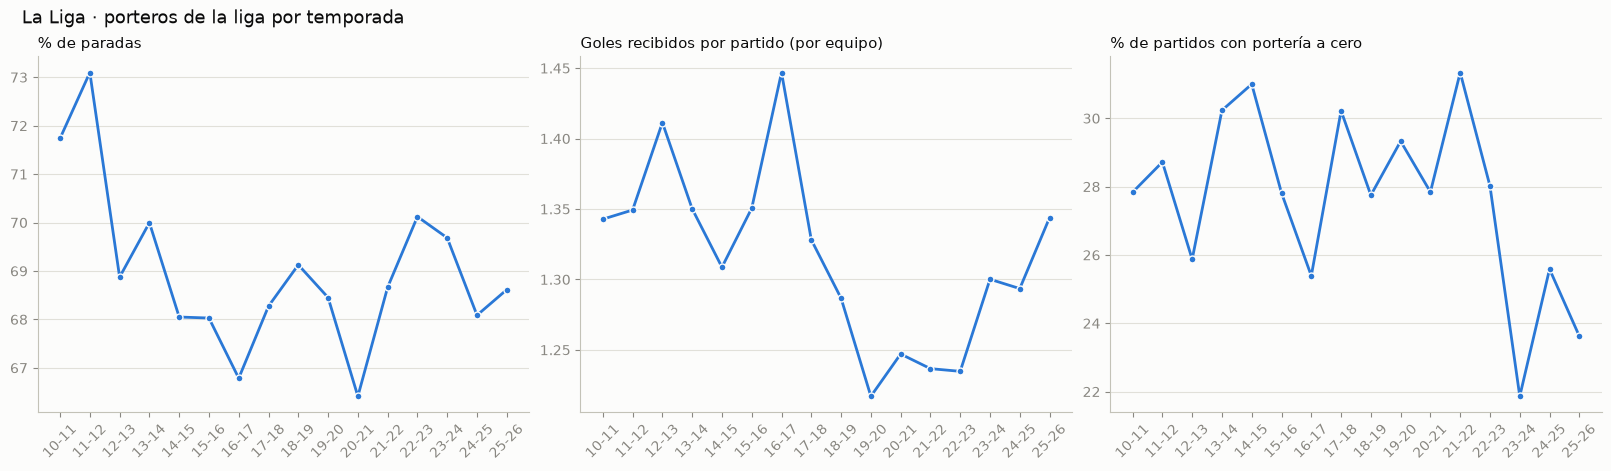

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **El % de paradas cae menos que en las otras ligas**: de 71.7% (2010-11) a 68.6% (2025-26), con el mínimo en
  2020-21 (66.4%).
- **Es la liga con menos goles**: los goles recibidos por partido bajaron a 1.22-1.30 entre 2018-19 y 2024-25, contra
  1.3-1.6 de la Premier.
- **Porterías a cero**: entre 22% y 31%, con las dos temporadas más bajas al final (21.9% en 2023-24 y 23.6% en
  2025-26).

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
ecada4fc,Keylor Navas,Levante / Real Madrid,2011,2018,151.0,76.70,33.77,1.00
ee8508c0,Jan Oblak,Atlético Madrid,2014,2025,399.0,75.54,46.12,0.79
a179d516,Willy Caballero,Málaga,2010,2013,117.0,74.00,32.48,1.18
6f51e382,Marc-André ter Stegen,Barcelona / Girona,2015,2025,293.0,73.96,43.00,0.89
1840e36d,Thibaut Courtois,Atlético Madrid / Real Madrid,2011,2025,343.0,73.87,43.15,0.86
e029e404,Víctor Valdés,Barcelona,2010,2013,124.0,73.73,43.55,0.80
6c4776b1,Jeremías Ledesma,Cádiz,2020,2023,138.0,72.88,29.71,1.39
011d8c56,Miguel Ángel Moyá,Valencia / Getafe / Atlético Madrid / Real Soc...,2010,2019,167.0,72.18,28.74,1.21
10072610,Claudio Bravo,Real Sociedad / Barcelona / Real Betis,2010,2023,269.0,72.06,36.80,1.16


Estabilidad año a año — % de paradas: r = 0.27 (174 pares); % porterías a cero: r = 0.40 (174 pares)


Entre los 44 porteros con 100+ partidos, el mejor % de paradas es de **Keylor Navas** (76.7%, Levante y Real Madrid),
pero **Jan Oblak** domina las otras dos métricas con muchísimos más partidos: 46.1% de porterías a cero y 0.79 goles
recibidos por 90 en 399 partidos con el Atlético. Después aparecen Ter Stegen, Courtois y Víctor Valdés.

Estabilidad año a año: % de paradas r = 0.27 (la más baja de las tres ligas) y % de porterías a cero r = **0.40** (la
más alta). En La Liga, quién recibe pocos goles depende más del equipo que del portero: el Atlético, el Barcelona y el
Real Madrid concedían muy poco durante años seguidos.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
24095,Joan García,Barcelona,30.0,77.9,15.0,21.0,21.0
23969,David Soria,Getafe,38.0,74.7,12.0,38.0,38.0
23819,Aarón Escandell,Oviedo,36.0,72.1,10.0,56.0,56.0
24345,Thibaut Courtois,Real Madrid,32.0,71.4,13.0,28.0,28.0
24205,Marko Dmitrović,Espanyol,37.0,71.1,10.0,54.0,54.0
23893,Augusto Batalla,Rayo Vallecano,34.0,71.1,11.0,37.0,37.0
24275,Paulo Gazzaniga,Girona,35.0,71.0,6.0,47.0,47.0
24076,Jan Oblak,Atlético Madrid,30.0,70.8,11.0,31.0,31.0
24411,Álvaro Vallés,Real Betis,28.0,70.7,8.0,36.0,36.0
24327,Sergio Herrera,Osasuna,37.0,70.6,7.0,47.0,47.0


Porteros-temporada con ambos datos: 531; no coinciden: 36. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,4,3,3,1,2,3,4,4,3,4,2,3
porteros,43,43,48,51,43,44,41,45,43,46,45,39


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
21933,Rúben Vezo,2021-2022,Levante,1.0,0.0,55.0,55.0
19305,Brais Méndez,2017-2018,Celta Vigo,1.0,0.0,18.0,18.0
23839,Aitor Fernández,2025-2026,Osasuna,2.0,3.0,8.0,5.0
21782,Manolo Reina,2021-2022,Mallorca,21.0,26.0,31.0,5.0
21303,Roberto,2020-2021,Valladolid,13.0,17.0,21.0,4.0


En 2025-26 encabeza **Joan García** (Barcelona, 77.9% de paradas y 15 porterías a cero), seguido de David Soria
(Getafe, 74.7%) y Aarón Escandell (Oviedo, 72.1%); los últimos con 900+ minutos son Julen Agirrezabala (Valencia,
62.7%) y Álex Remiro (Real Sociedad, 62.3%).

**Calidad de datos**: entre 1 y 4 porteros por temporada tienen distinto número de goles recibidos en las dos tablas
de FBref. Es un punto intermedio entre la Premier (casi ninguno) y la Liga MX de 2014-16 (más de la mitad).

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

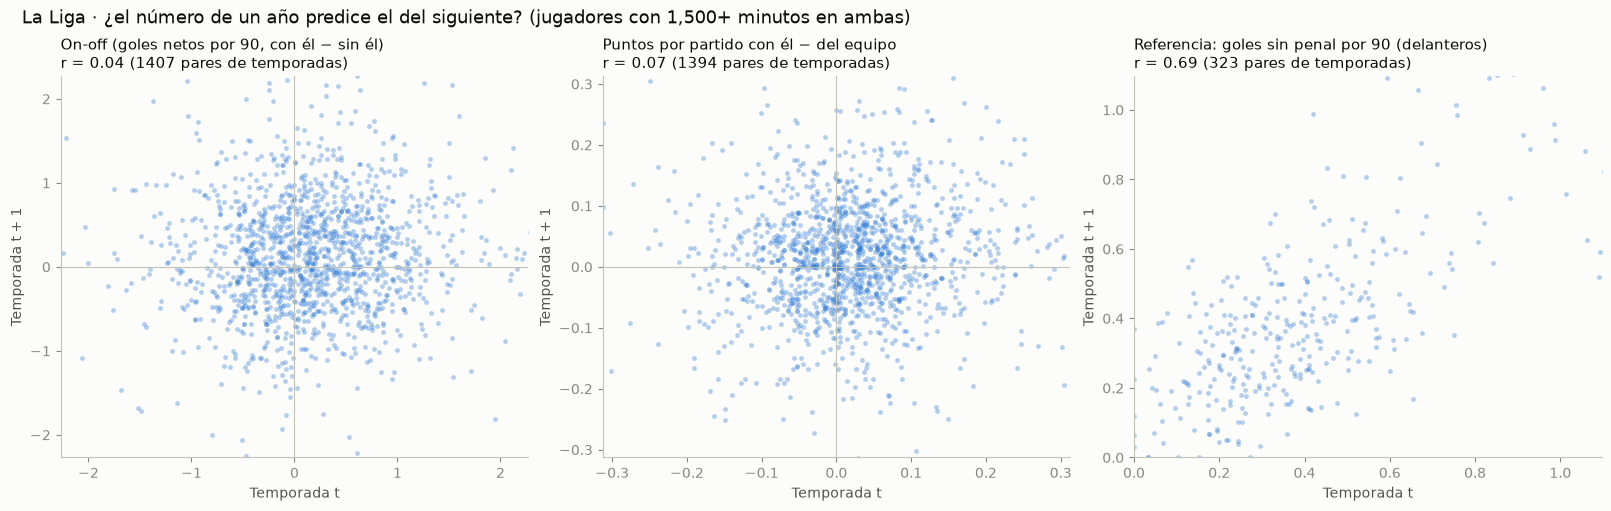

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.04,1407.0
Puntos por partido con él − del equipo,0.07,1394.0
Referencia: goles sin penal por 90 (delanteros),0.69,323.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

Tercera liga, mismo resultado:

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.04** (1,407 pares) |
| Puntos por partido con él − del equipo | **0.07** (1,394 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.69** (323 pares) |

La medida individual de referencia es la más estable de las tres ligas (0.69 contra 0.62 de la Premier y 0.52 de la
Liga MX), y aun así el on-off sigue pegado a cero. No es un problema de una liga: es lo que pasa cuando se mide
"impacto" con totales de temporada.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

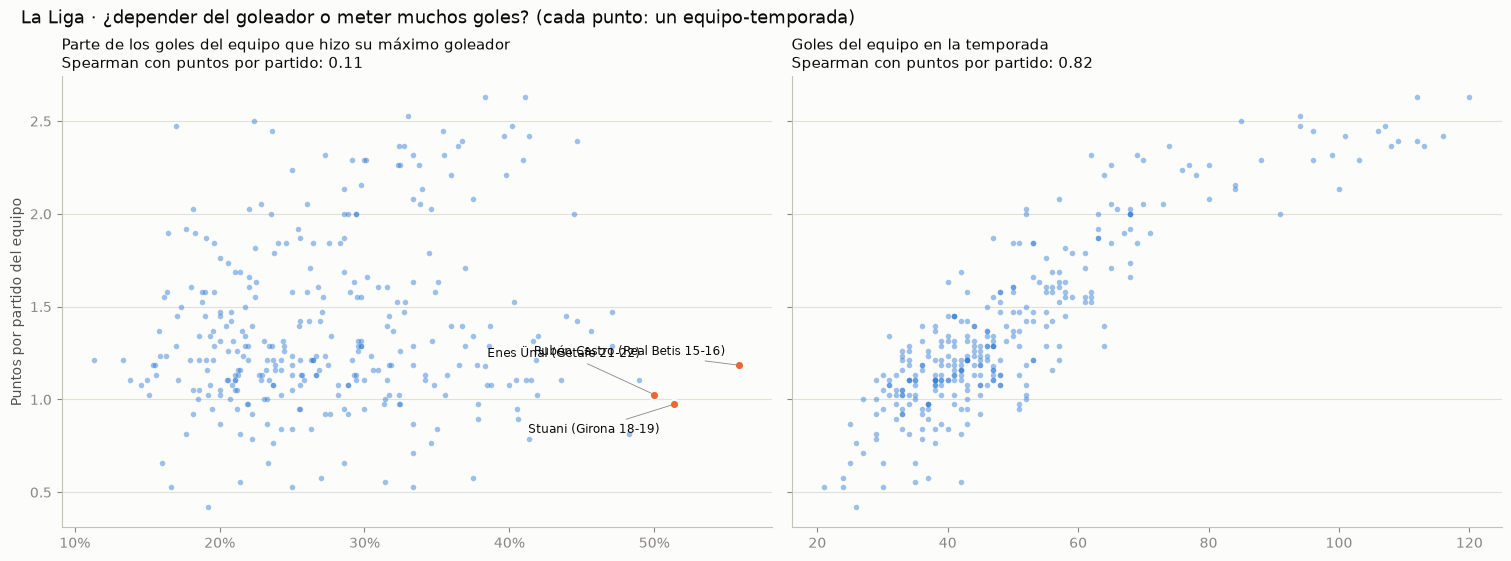

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
119,2015-2016,Real Betis,Rubén Castro,19.0,34.0,0.56,1.18
168,2018-2019,Girona,Cristhian Stuani,19.0,37.0,0.51,0.97
227,2021-2022,Getafe,Enes Ünal,16.0,32.0,0.50,1.03
303,2025-2026,Mallorca,Vedat Muriqi,23.0,47.0,0.49,1.11
228,2021-2022,Alavés,Joselu,14.0,29.0,0.48,0.82
35,2011-2012,Atlético Madrid,Radamel Falcao,24.0,51.0,0.47,1.47
152,2017-2018,Espanyol,Gerard Moreno,16.0,34.0,0.47,1.29
281,2024-2025,Osasuna,Ante Budimir,21.0,46.0,0.46,1.37


Mediana de la dependencia por temporada: {'2010-2011': 0.28, '2011-2012': 0.29, '2012-2013': 0.3, '2013-2014': 0.27, '2014-2015': 0.29, '2015-2016': 0.31, '2016-2017': 0.23, '2017-2018': 0.26, '2018-2019': 0.3, '2019-2020': 0.26, '2020-2021': 0.29, '2021-2022': 0.22, '2022-2023': 0.23, '2023-2024': 0.24, '2024-2025': 0.27, '2025-2026': 0.24}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- **Depender del goleador tampoco da puntos** (0.11, el valor más alto de las tres ligas pero igualmente bajo); los
  goles del equipo sí (0.82).
- Los más dependientes: **Rubén Castro** hizo el 56% de los goles del Betis 2015-16, **Cristhian Stuani** el 51% del
  Girona 2018-19 y **Vedat Muriqi** el 49% del Mallorca 2025-26. El caso con mejores resultados es **Radamel Falcao**:
  47% de los goles del Atlético 2011-12, con 1.47 puntos por partido.
- La dependencia mediana se mueve entre 22% y 31% sin tendencia clara.

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
24368,Mallorca,Vedat Muriqi,FW,23.0,1.0,157.0,1219.0,0.13,98.04
24152,Real Madrid,Kylian Mbappé,FW,25.0,5.0,169.0,1427.0,0.12,100.00
24352,Alavés,Toni Martínez,FW,14.0,3.0,132.0,1156.0,0.11,90.20
23875,Osasuna,Ante Budimir,FW,17.0,0.0,133.0,1183.0,0.11,93.14
24154,Barcelona,Lamine Yamal,MF,16.0,11.0,164.0,1600.0,0.10,100.00
24226,Real Sociedad,Mikel Oyarzabal,FW,15.0,4.0,133.0,1299.0,0.10,93.14
24261,Real Betis,Pablo Fornals,MF,9.0,6.0,132.0,1322.0,0.10,99.33
24217,Getafe,Mauro Arambarri,MF,6.0,2.0,102.0,1063.0,0.10,90.67
23923,Espanyol,Carlos Romero,DF,6.0,3.0,113.0,1203.0,0.09,100.00
23846,Villarreal,Alberto Moleiro,MF,10.0,5.0,128.0,1394.0,0.09,98.67


En 2025-26 el mejor jugador fantasy de cada equipo aporta entre el 7% (Etta Eyong, Levante) y el 13% (**Vedat
Muriqi**, Mallorca) de los puntos fantasy de su equipo. Los puntajes más altos son de **Kylian Mbappé** (169, Real
Madrid) y **Lamine Yamal** (164, Barcelona), ambos en el percentil 100 de su posición. La excepción de la lista es
**Carlos Romero** (Espanyol), un defensa con 113 puntos y percentil 100 entre defensas.

## 5. Conclusiones y cómo ampliar a otra liga

**La Liga, 2010-11 a 2025-26, frente a Liga MX y Premier:**

1. **Plantillas**: rotación creciente pero moderada (14-15.5 jugadores para el 80% de los minutos). Es la liga más
   local de las tres: los extranjeros oscilan entre 36% y 47% de los minutos, sin tendencia, contra el 73% de la
   Premier. Rotar se asocia con perder (−0.28).
2. **Porteros**: la caída del % de paradas es la más suave (71.7% → 68.6%) y es la liga con menos goles recibidos por
   partido. Keylor Navas tiene el mejor % de paradas; Oblak, las mejores porterías a cero y goles recibidos, con 399
   partidos. Las porterías a cero son lo más estable año a año de las tres ligas (0.40): pesa mucho el equipo.
3. **Impacto en cancha**: on-off 0.04 y puntos con él 0.07, con la referencia individual más alta (0.69). El
   patrón se repite en las tres ligas.
4. **Dependencia**: 0.11 con los puntos, goles del equipo 0.82. Falcao en el Atlético 2011-12 es el caso más
   productivo de dependencia alta.

**Calidad de datos**: 2011-12 tiene cuatro equipos sin resultados confiables (Mallorca, Getafe, Levante y Real Betis),
que aparecen vacíos en vez de con un número inventado.